### Andrea Márquez Sánchez - 1036449719
# Taller Análisis Exploratorio de Datos

In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Paso 1: Carga de datos

Abra el archivo en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargar el archivo dado, que contiene un dataset cuya información puede consultar en [UCI](https://archive.ics.uci.edu/dataset/27/credit+approval).

De a las columnas los siguientes nombres: 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15'.

Responda las siguientes preguntas:

- ¿Cuántas filas y columnas tiene el dataframe?
- ¿De qué tipo de dato es cada columna?
- ¿Las variables están en el tipo de dato correcto para su contenido?


In [65]:
#Cargamos las librerias que vamos a usar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
columnas = [
    'A0','A1','A2','A3','A4','A5','A6','A7','A8',
    'A9','A10','A11','A12','A13','A14','A15'
]

df = pd.read_csv('/crx.data', header=None, names=columnas)

# Reemplazar ? por NaN
df = df.replace('?', np.nan)

# Convertir variables numéricas
numericas = ['A2','A3','A8','A11','A14'] # Removed 'A15'

for col in numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Filas y columnas:', df.shape)

Filas y columnas: (690, 16)


**¿Cuántas filas y columnas tiene el dataframe?**
- Como nos muestra el codigo tenemos 690 filas y 16 columnas

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A0      678 non-null    object 
 1   A1      678 non-null    object 
 2   A2      690 non-null    float64
 3   A3      0 non-null      float64
 4   A4      684 non-null    object 
 5   A5      681 non-null    object 
 6   A6      681 non-null    object 
 7   A7      690 non-null    float64
 8   A8      0 non-null      float64
 9   A9      690 non-null    object 
 10  A10     690 non-null    int64  
 11  A11     0 non-null      float64
 12  A12     690 non-null    object 
 13  A13     677 non-null    object 
 14  A14     690 non-null    int64  
 15  A15     690 non-null    object 
dtypes: float64(5), int64(2), object(9)
memory usage: 86.4+ KB


In [68]:
tipos = pd.DataFrame(df.dtypes, columns=['Tipo'])
print(tipos)

        Tipo
A0    object
A1    object
A2   float64
A3   float64
A4    object
A5    object
A6    object
A7   float64
A8   float64
A9    object
A10    int64
A11  float64
A12   object
A13   object
A14    int64
A15   object


**¿De qué tipo de dato es cada columna?**
Segun lo que podemos ver tenemos que

- A0    object

- A1    object

- A2   float64

- A3   float64

- A4    object

- A5    object

- A6    object

- A7   float64

- A8   float64

- A9    object

- A10    int64

- A11  float64

- A12   object

- A13   object

- A14    int64

- A15  float64


**¿Las variables están en el tipo de dato correcto para su contenido?**

- Sí. Las variables categóricas (A0, A1, A4, A5, A6, A9, A12 y A13) están almacenadas como object, lo cual es adecuado para datos cualitativos. Las variables cuantitativas (A2, A3, A7, A8, A10, A11, A14 y A15) están almacenadas como tipos numéricos (float64 o int64), por lo que son apropiadas para realizar análisis estadísticos.


## Paso 2: Exploración inicial de los datos

Responda las siguientes preguntas:

- ¿Hay valores fuera de rango o imposibles, según el dominio del problema?
- ¿Hay variables que no varían?
- Qué variables *cualitativas* tienen muchos valores únicos (alta cardinalidad)?
- ¿Hay claves primarias o identificadores únicos?

In [69]:
numericas =  ['A1','A2','A7','A10','A13','A14']
categoricas = [c for c in df.columns if c not in numericas]

**¿Hay valores fuera de rango o imposibles, según el dominio del problema?**

In [70]:
for col in numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')


for col in numericas:
    print(f'\nVariable: {col}')
    print('Mínimo:', df[col].min())
    print('Máximo:', df[col].max())


Variable: A1
Mínimo: 13.75
Máximo: 80.25

Variable: A2
Mínimo: 0.0
Máximo: 28.0

Variable: A7
Mínimo: 0.0
Máximo: 28.5

Variable: A10
Mínimo: 0
Máximo: 67

Variable: A13
Mínimo: 0.0
Máximo: 2000.0

Variable: A14
Mínimo: 0
Máximo: 100000


Con base en estos resultados, no se identificaron valores claramente imposibles o fuera de rango para el contexto de aprobación de crédito. Los valores observados son plausibles y coherentes con el dominio del problema.


**¿Hay variables que no varían?**


In [71]:
# Número de valores únicos por variable
variacion = df.nunique(dropna=False)
print(variacion)

A0       3
A1     350
A2     215
A3       1
A4       4
A5      15
A6      10
A7     132
A8       1
A9       2
A10     23
A11      1
A12      3
A13    171
A14    240
A15      2
dtype: int64


In [72]:
cardinalidad = df[categoricas].nunique().sort_values(ascending=False)
print(cardinalidad)

A5     14
A6      9
A4      3
A12     3
A15     2
A0      2
A9      2
A3      0
A8      0
A11     0
dtype: int64


Se evaluó el número de valores únicos de cada variable. Se observó que las variables A3, A8, A11 y A15 presentan 0 valores únicos en el análisis realizado, por lo que no muestran variación y no aportan información útil para el estudio. Las demás variables presentan más de un valor distinto, por lo que sí contienen variabilidad en los datos.

**Qué variables cualitativas tienen muchos valores únicos (alta cardinalidad)?**

In [73]:
cardinalidad = df[categoricas].nunique().sort_values(ascending=False)
print(cardinalidad)

A5     14
A6      9
A4      3
A12     3
A15     2
A0      2
A9      2
A3      0
A8      0
A11     0
dtype: int64


Las variables categóricas con mayor número de categorías son A5 y A6, por lo que son las variables de mayor cardinalidad dentro del conjunto de datos. Las demás variables categóricas presentan un número reducido de categorías.

**¿Hay claves primarias o identificadores únicos?**

In [74]:
for col in df.columns:
    unicos = df[col].nunique(dropna=False)
    if unicos == len(df):
        print(f'{col} podría ser un identificador único')

Ninguna variable tiene un número de valores únicos igual al número total de registros (690). Por lo tanto, no se identificaron claves primarias ni identificadores únicos en el conjunto de datos.


## Paso 3: Identificación de datos duplicados, datos nulos y problemas de formateo

Descarte las variables que solo toman un valor y las que son clave primaria. También descarte las variables **City** y **Lat Long**.

Responda las siguientes preguntas:

- ¿Qué variables tienen valores nulos? ¿En qué proporción?
- ¿Hay registros duplicados?
- ¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?

**¿Qué variables tienen valores nulos? ¿En qué proporción?**

In [75]:
nulos = df.isnull().sum()

# Calcular porcentaje de nulos
porcentaje_nulos = (nulos / len(df)) * 100

# Crear tabla resumen
tabla_nulos = pd.DataFrame({
    'Valores nulos': nulos,
    'Porcentaje (%)': porcentaje_nulos.round(2)
})

tabla_nulos.sort_values('Porcentaje (%)', ascending=False)

,Valores nulos,Porcentaje (%)
A3,690,100.00
A8,690,100.00
A11,690,100.00
A13,13,1.88
A1,12,1.74
A0,12,1.74
A6,9,1.30
A5,9,1.30
A4,6,0.87
A2,0,0.00


Se realizó un análisis de valores faltantes en todas las variables del conjunto de datos. Se identificaron las columnas que contienen valores nulos y se calculó el porcentaje de datos faltantes respecto al total de registros. Las variables con mayor proporción de valores nulos son las que requerirán tratamiento durante la etapa de limpieza de datos, ya sea mediante imputación o eliminación de registros según corresponda.

**¿Hay registros duplicados?**

In [76]:
duplicados = df.duplicated().sum()

print("Número de registros duplicados:", duplicados)

Número de registros duplicados: 1


In [77]:
df[df.duplicated()]

,A0,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
315,b,23.0,0.75,NaN,g,m,v,0.5,NaN,f,0,NaN,s,320.0,0,-


Se verificó la existencia de registros duplicados utilizando la función duplicated() de Pandas.


Se identificaron 1 registro duplicado, el cuales podrían eliminarse para evitar sesgos en análisis posteriores.

**¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?**

Revisar variables categóricas:


In [78]:
categoricas = df.select_dtypes(include='object').columns

for col in categoricas:
    print(f"\nVariable: {col}")
    print(df[col].unique()[:20])


Variable: A0
['b' 'a' nan]

Variable: A4
['g' 'p' nan 'gg']

Variable: A5
['w' 'q' 'm' 'r' 'cc' 'k' 'c' 'd' 'x' 'i' 'e' 'aa' 'ff' 'j' nan]

Variable: A6
['v' 'h' 'bb' 'ff' 'j' 'z' nan 'o' 'dd' 'n']

Variable: A9
['t' 'f']

Variable: A12
['g' 's' 'p']

Variable: A15
['+' '-']


Buscar espacios en blanco:


In [79]:
for col in categoricas:
    espacios = df[col].astype(str).str.contains(r'^\s+|\s+$', regex=True).sum()
    print(f"{col}: {espacios} valores con espacios")

A0: 0 valores con espacios
A4: 0 valores con espacios
A5: 0 valores con espacios
A6: 0 valores con espacios
A9: 0 valores con espacios
A12: 0 valores con espacios
A15: 0 valores con espacios


Buscar diferencias de mayúsculas/minúsculas:

In [80]:
for col in categoricas:
    print(f"\n{col}")
    print(df[col].astype(str).str.lower().nunique(),
          "categorías ignorando mayúsculas")


A0
3 categorías ignorando mayúsculas

A4
4 categorías ignorando mayúsculas

A5
15 categorías ignorando mayúsculas

A6
10 categorías ignorando mayúsculas

A9
2 categorías ignorando mayúsculas

A12
3 categorías ignorando mayúsculas

A15
2 categorías ignorando mayúsculas




Se realizó una revisión de las variables categóricas (`A0`, `A4`, `A5`, `A6`, `A9` y `A12`) para identificar posibles problemas de formateo. Los resultados mostraron que no existen valores con espacios en blanco adicionales en ninguna de las variables analizadas. Asimismo, al comparar las categorías ignorando mayúsculas y minúsculas, no se evidenciaron inconsistencias en la escritura de las categorías.

También se observó que las variables presentan un número coherente de categorías: `A5` es la variable con mayor diversidad de categorías (15), seguida de `A6` (10), mientras que `A0` y `A9` presentan únicamente dos categorías.

En conclusión, no se identificaron problemas significativos de formateo relacionados con espacios, mayúsculas/minúsculas, fechas o monedas, por lo que las variables categóricas se consideran consistentes y aptas para continuar con el análisis exploratorio de datos.


## Paso 4: Análisis de variables cuantitativas

Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no.

Haga un análisis gráfico de outliers, y como resultado de este indique que variables tienen datos atípicos.

**Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no.**

In [81]:
from scipy.stats import shapiro

# Variables cuantitativas
variables_cuantitativas = ['A1', 'A2', 'A7', 'A10', 'A13', 'A14']

# Aplicar prueba de Shapiro-Wilk
for variable in variables_cuantitativas:

    # Eliminar valores nulos antes de realizar la prueba
    datos = df[variable].dropna()

    estadistico, p_valor = shapiro(datos)

    print(f'Variable: {variable}')
    print(f'Estadístico: {estadistico:.4f}')
    print(f'Valor p: {p_valor:.6e}')

    if p_valor > 0.05:
        print('Conclusión: cumple con el supuesto de normalidad')
    else:
        print('Conclusión: NO cumple con el supuesto de normalidad')

    print('-' * 50)

Variable: A1
Estadístico: 0.9082
Valor p: 8.814178e-20
Conclusión: NO cumple con el supuesto de normalidad
--------------------------------------------------
Variable: A2
Estadístico: 0.8303
Valor p: 2.009391e-26
Conclusión: NO cumple con el supuesto de normalidad
--------------------------------------------------
Variable: A7
Estadístico: 0.6653
Valor p: 1.109684e-34
Conclusión: NO cumple con el supuesto de normalidad
--------------------------------------------------
Variable: A10
Estadístico: 0.5331
Valor p: 3.662318e-39
Conclusión: NO cumple con el supuesto de normalidad
--------------------------------------------------
Variable: A13
Estadístico: 0.8208
Valor p: 8.376486e-27
Conclusión: NO cumple con el supuesto de normalidad
--------------------------------------------------
Variable: A14
Estadístico: 0.1699
Valor p: 1.405343e-47
Conclusión: NO cumple con el supuesto de normalidad
--------------------------------------------------


Se realizó la prueba de normalidad de Shapiro-Wilk sobre las variables cuantitativas A1, A2, A7, A10, A13 y A14. Se utilizó un nivel de significancia de 0.05. En todos los casos se obtuvieron valores de p inferiores a 0.05, por lo que se rechaza la hipótesis nula de normalidad.

Por lo tanto, ninguna de las variables cuantitativas analizadas cumple con el supuesto de normalidad.

**Haga un análisis gráfico de outliers, y como resultado de este indique que variables tienen datos atípicos.**

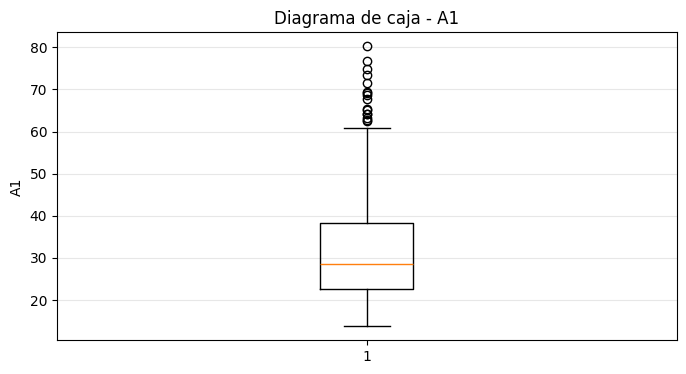

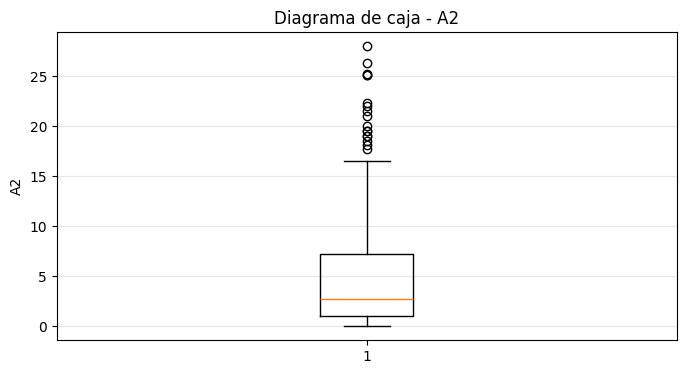

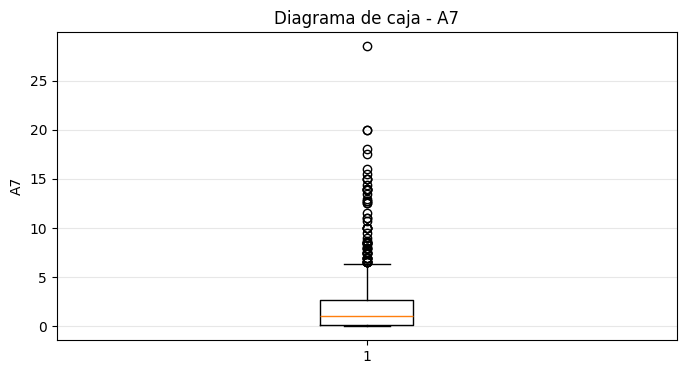

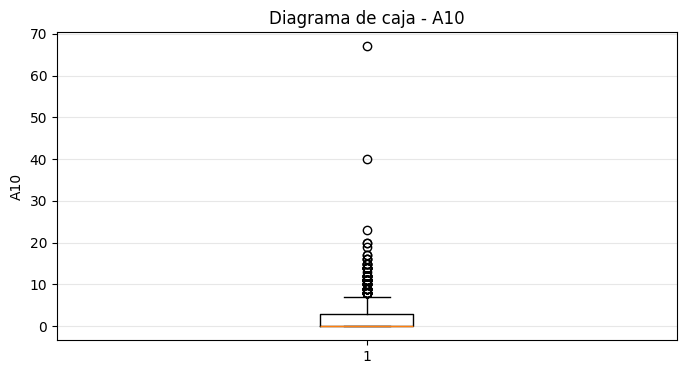

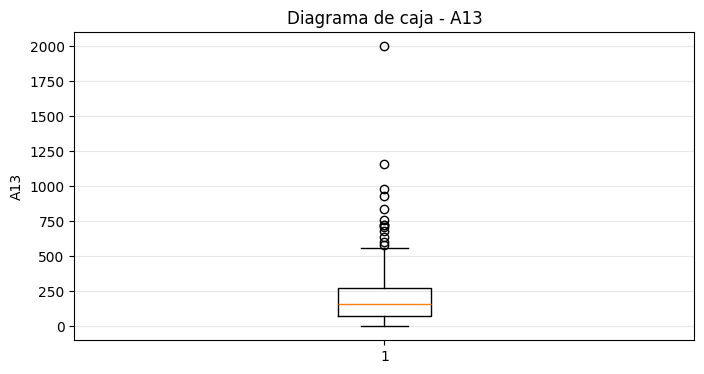

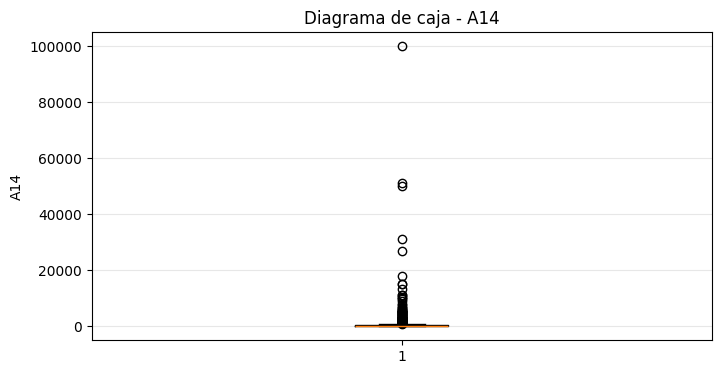

In [82]:

for variable in variables_cuantitativas:

    plt.figure(figsize=(8, 4))

    plt.boxplot(df[variable].dropna())

    plt.title(f'Diagrama de caja - {variable}')
    plt.ylabel(variable)
    plt.grid(axis='y', alpha=0.3)

    plt.show()

In [83]:
for variable in variables_cuantitativas:

    datos = df[variable].dropna()

    Q1 = datos.quantile(0.25)
    Q3 = datos.quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = datos[
        (datos < limite_inferior) |
        (datos > limite_superior)
    ]

    print(f'Variable: {variable}')
    print(f'Límite inferior: {limite_inferior:.2f}')
    print(f'Límite superior: {limite_superior:.2f}')
    print(f'Número de outliers: {len(outliers)}')
    print('-' * 50)

Variable: A1
Límite inferior: -0.84
Límite superior: 61.67
Número de outliers: 16
--------------------------------------------------
Variable: A2
Límite inferior: -8.31
Límite superior: 16.52
Número de outliers: 17
--------------------------------------------------
Variable: A7
Límite inferior: -3.52
Límite superior: 6.31
Número de outliers: 63
--------------------------------------------------
Variable: A10
Límite inferior: -4.50
Límite superior: 7.50
Número de outliers: 79
--------------------------------------------------
Variable: A13
Límite inferior: -226.50
Límite superior: 577.50
Número de outliers: 13
--------------------------------------------------
Variable: A14
Límite inferior: -593.25
Límite superior: 988.75
Número de outliers: 113
--------------------------------------------------


Con base en estos resultados se concluye que todas las variables cuantitativas presentan valores atípicos. La variable A14 es la que registra la mayor cantidad de observaciones atípicas (113), seguida de A10 (79) y A7 (63). Las variables A1, A2 y A13 presentan una menor cantidad de valores extremos.

La presencia de estos valores atípicos indica que las distribuciones de las variables cuantitativas son asimétricas y contienen observaciones extremas que podrían influir en medidas estadísticas como la media y la desviación estándar. Por esta razón, para etapas posteriores del análisis se recomienda utilizar medidas robustas como la mediana y considerar técnicas de tratamiento de outliers si se construyen modelos predictivos.

## Paso 5: Análisis de variables cualitativas

Responda a las siguientes preguntas:

- ¿Cómo se comportan las variables categóricas?
- ¿Existen variables de alta cardinalidad?
- ¿Existen categorías atípicas?

**¿Cómo se comportan las variables categóricas?**

In [84]:
variables_categoricas = ['A0', 'A4', 'A5', 'A6', 'A9', 'A12']

for variable in variables_categoricas:

    print(f'\nVariable: {variable}')
    print(df[variable].value_counts(dropna=False))
    print('-' * 40)


Variable: A0
A0
b      468
a      210
NaN     12
Name: count, dtype: int64
----------------------------------------

Variable: A4
A4
g      519
p      163
NaN      6
gg       2
Name: count, dtype: int64
----------------------------------------

Variable: A5
A5
c      137
q       78
w       64
i       59
aa      54
ff      53
k       51
cc      41
m       38
x       38
d       30
e       25
j       10
NaN      9
r        3
Name: count, dtype: int64
----------------------------------------

Variable: A6
A6
v      399
h      138
bb      59
ff      57
NaN      9
j        8
z        8
dd       6
n        4
o        2
Name: count, dtype: int64
----------------------------------------

Variable: A9
A9
f    395
t    295
Name: count, dtype: int64
----------------------------------------

Variable: A12
A12
g    625
s     57
p      8
Name: count, dtype: int64
----------------------------------------


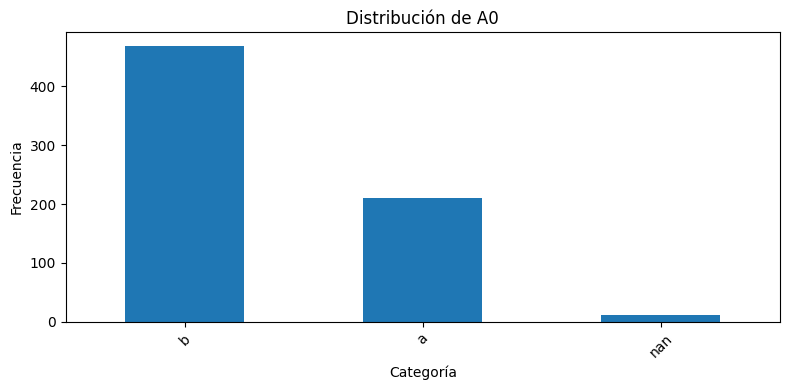

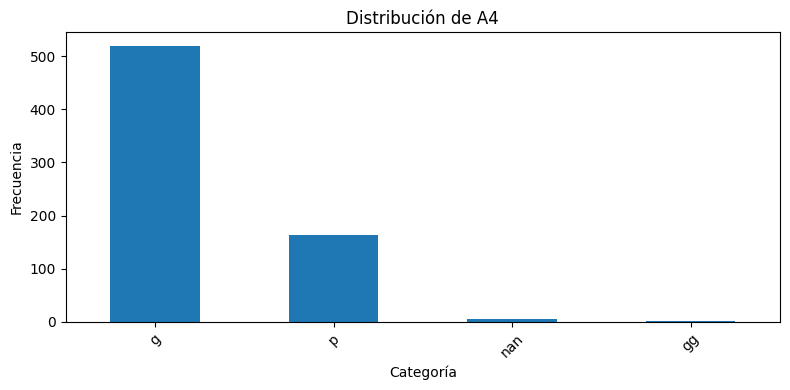

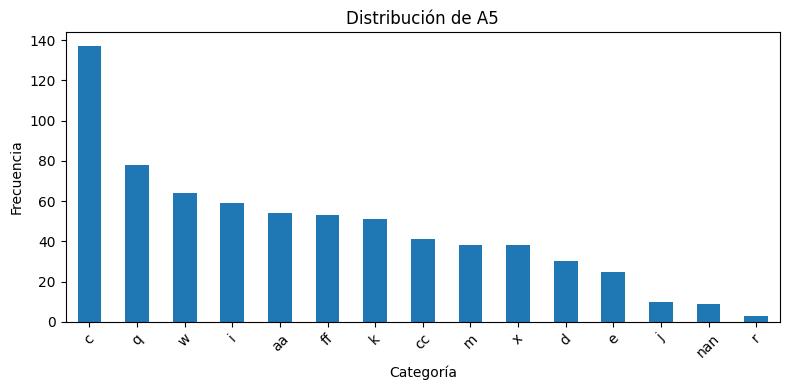

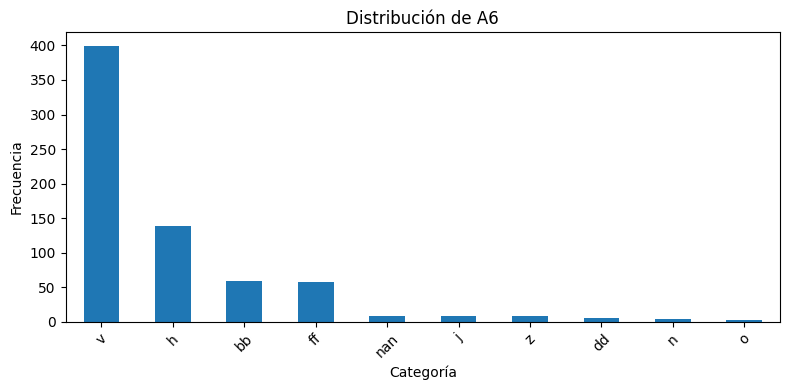

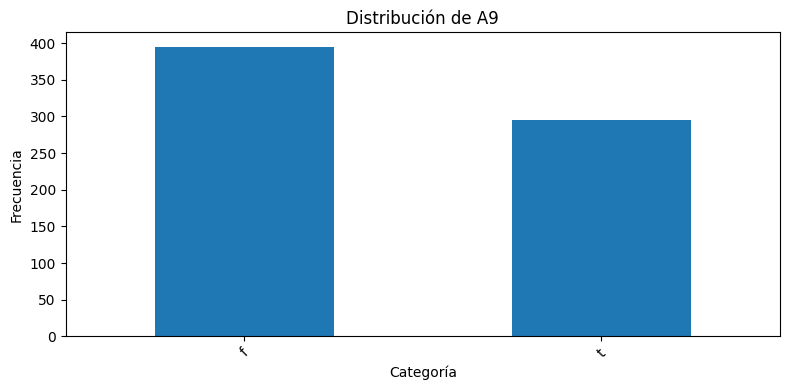

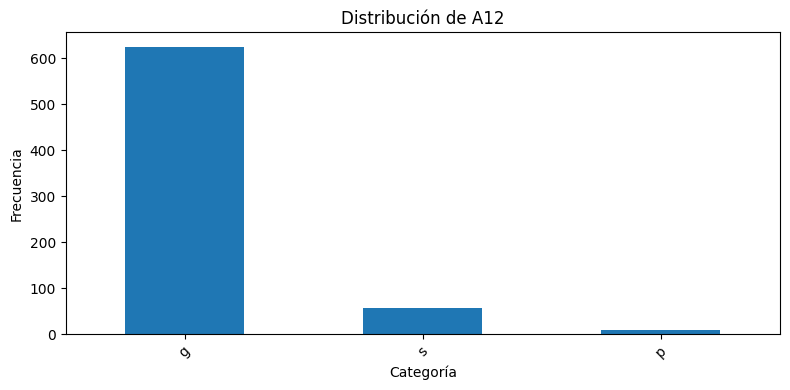

In [85]:
for variable in variables_categoricas:

    plt.figure(figsize=(8, 4))
    df[variable].value_counts(dropna=False).plot(kind='bar')

    plt.title(f'Distribución de {variable}')
    plt.xlabel('Categoría')
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Se analizaron las variables categóricas mediante tablas de frecuencia y gráficos de barras. Se observa que las variables presentan diferentes cantidades de categorías y que la frecuencia de estas no es uniforme. Algunas categorías aparecen con mayor frecuencia que otras, mientras que algunas presentan una menor cantidad de observaciones. En general, las variables categóricas presentan una distribución desigual entre sus categorías, por lo que existen categorías predominantes y otras con menor representación

**¿Existen variables de alta cardinalidad?**

In [86]:
for variable in variables_categoricas:

    cardinalidad = df[variable].nunique(dropna=True)

    print(f'{variable}: {cardinalidad} categorías únicas')

A0: 2 categorías únicas
A4: 3 categorías únicas
A5: 14 categorías únicas
A6: 9 categorías únicas
A9: 2 categorías únicas
A12: 3 categorías únicas


Se analizó la cardinalidad de las variables categóricas contando el número de categorías únicas de cada una. La variable A5 presenta la mayor cardinalidad con 14 categorías, seguida de A6 con 9 categorías. Las variables A4 y A12 presentan 3 categorías, mientras que A0 y A9 presentan 2 categorías. Aunque A5 y A6 tienen una mayor diversidad de categorías, no se considera que exista una variable con cardinalidad excesivamente alta, debido a que el número de categorías sigue siendo pequeño en relación con el tamaño total del conjunto de datos.

**¿Existen categorías atípicas?**

In [87]:
for variable in variables_categoricas:

    frecuencias = df[variable].value_counts(dropna=False)

    categorias_atipicas = frecuencias[frecuencias <= 5]

    print(f'\nVariable: {variable}')
    print('Categorías con 5 o menos registros:')
    print(categorias_atipicas)
    print('-' * 40)


Variable: A0
Categorías con 5 o menos registros:
Series([], Name: count, dtype: int64)
----------------------------------------

Variable: A4
Categorías con 5 o menos registros:
A4
gg    2
Name: count, dtype: int64
----------------------------------------

Variable: A5
Categorías con 5 o menos registros:
A5
r    3
Name: count, dtype: int64
----------------------------------------

Variable: A6
Categorías con 5 o menos registros:
A6
n    4
o    2
Name: count, dtype: int64
----------------------------------------

Variable: A9
Categorías con 5 o menos registros:
Series([], Name: count, dtype: int64)
----------------------------------------

Variable: A12
Categorías con 5 o menos registros:
Series([], Name: count, dtype: int64)
----------------------------------------


In [88]:
for variable in variables_categoricas:

    frecuencias = df[variable].value_counts(dropna=False)
    porcentajes = (frecuencias / len(df)) * 100

    resultado = pd.DataFrame({
        'Frecuencia': frecuencias,
        'Porcentaje': porcentajes.round(2)
    })

    print(f'\nVariable: {variable}')
    print(resultado[resultado['Frecuencia'] <= 5])


Variable: A0
Empty DataFrame
Columns: [Frecuencia, Porcentaje]
Index: []

Variable: A4
    Frecuencia  Porcentaje
A4                        
gg           2        0.29

Variable: A5
    Frecuencia  Porcentaje
A5                        
r            3        0.43

Variable: A6
    Frecuencia  Porcentaje
A6                        
n            4        0.58
o            2        0.29

Variable: A9
Empty DataFrame
Columns: [Frecuencia, Porcentaje]
Index: []

Variable: A12
Empty DataFrame
Columns: [Frecuencia, Porcentaje]
Index: []


Se identificaron categorías poco frecuentes considerando aquellas con cinco o menos observaciones. Los resultados fueron:

- En A4, la categoría gg aparece 2 veces (0.29%).
- En A5, la categoría r aparece 3 veces (0.43%).
- En A6, la categoría n aparece 4 veces (0.58%) y la categoría o aparece 2 veces (0.29%).

Las variables A0, A9 y A12 no presentaron categorías con frecuencias menores o iguales a cinco observaciones.

En conclusión, sí existen categorías atípicas o poco frecuentes en las variables A4, A5 y A6. Estas categorías representan una proporción muy pequeña del conjunto de datos y podrían requerir tratamiento especial en etapas posteriores del análisis o en la construcción de modelos predictivos.

## Paso 6: Análisis bivariado

Se va a suponer que con este archivo de datos se desea hacer un modelo de aprendizaje de máquina que prediga la vaariable **A15**.


Mediante análisis de gráficas responda las siguientes preguntas:

- ¿Cómo se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?
- ¿Cómo se relaciona cada una de las variables cualitativas con la variable que se desea predecir?
- De acuerdo con estos análisis, ¿cuáles variables parecerían ser buenas predictoras, y cuáles no?


**¿Cómo se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?**

In [89]:
variables_cuantitativas = ['A1', 'A2', 'A7', 'A10', 'A13', 'A14']

variables_categoricas = ['A0', 'A4', 'A5', 'A6', 'A9', 'A12'] # Corrected list

# Convertir A15 a variable binaria para los análisis numéricos
df['A15_bin'] = df['A15'].map({'+': 1, '-': 0})

print(df['A15_bin'].value_counts())

A15_bin
0    383
1    307
Name: count, dtype: int64


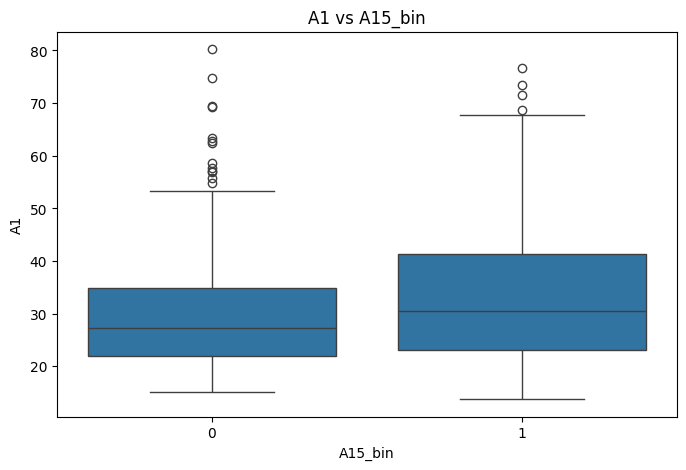

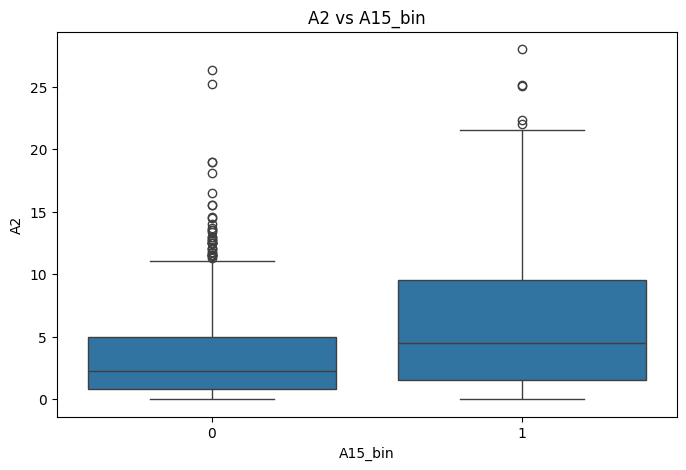

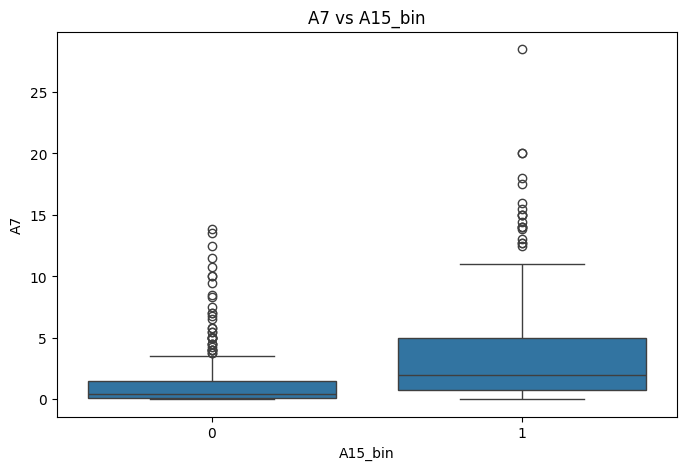

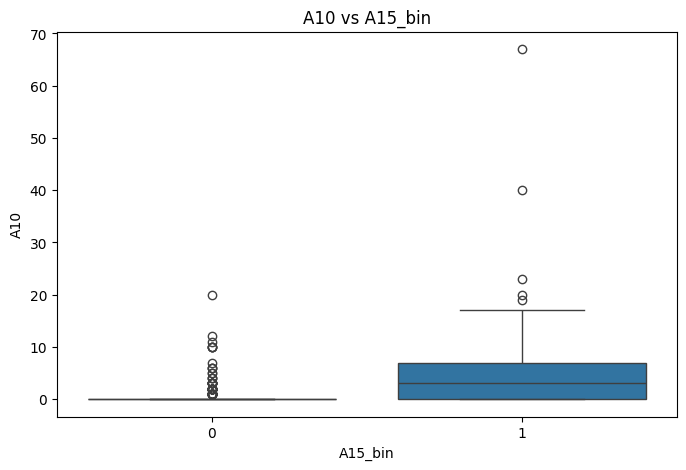

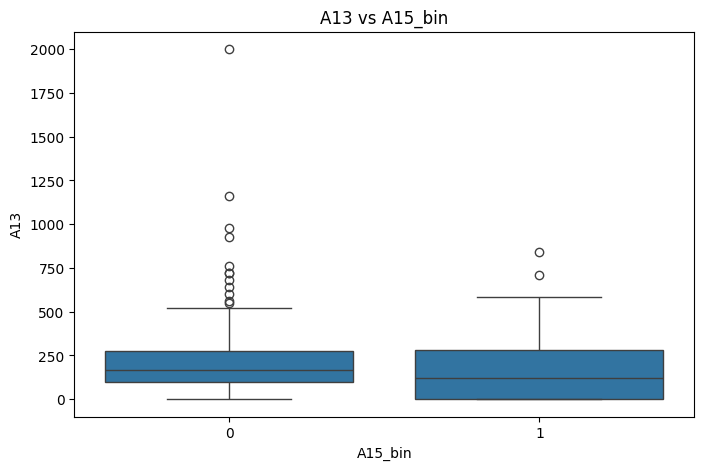

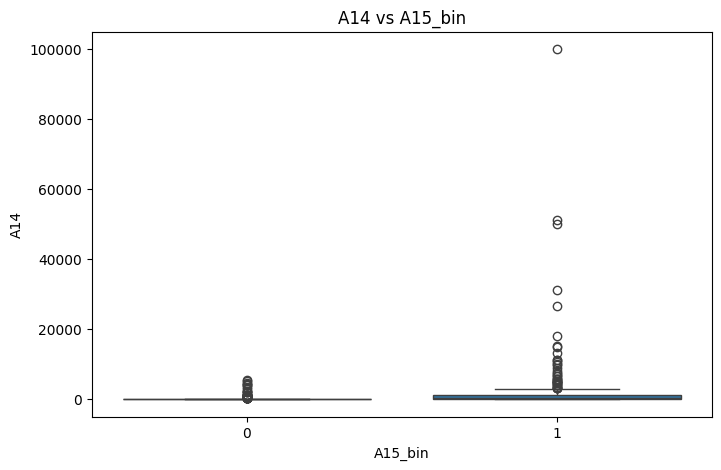

In [90]:
for variable in variables_cuantitativas:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x='A15_bin', # Changed x to 'A15_bin'
        y=variable
    )

    plt.title(f'{variable} vs A15_bin') # Updated title
    plt.xlabel('A15_bin') # Updated label
    plt.ylabel(variable)
    plt.show()

In [91]:
for variable in variables_cuantitativas:

    datos = df[[variable, 'A15_bin']].dropna()

    correlacion = datos[variable].corr(datos['A15_bin'])

    print(f'{variable}: correlación = {correlacion:.3f}')

A1: correlación = 0.163
A2: correlación = 0.206
A7: correlación = 0.322
A10: correlación = 0.406
A13: correlación = -0.101
A14: correlación = 0.176


Se utilizaron diagramas de caja para analizar la relación entre las variables cuantitativas y la variable objetivo A15. Se observaron diferencias entre las distribuciones de las clases de A15 para varias variables. Entre las variables cuantitativas, A10 presenta la relación más marcada con A15, seguida de A7 y A2. Las variables A1 y A14 presentan relaciones más débiles, mientras que A13 presenta una relación débil y negativa. Por lo tanto, A10 y A7 parecen tener mayor capacidad predictiva de manera individual.

**¿Cómo se relaciona cada una de las variables cualitativas con la variable que se desea predecir?**

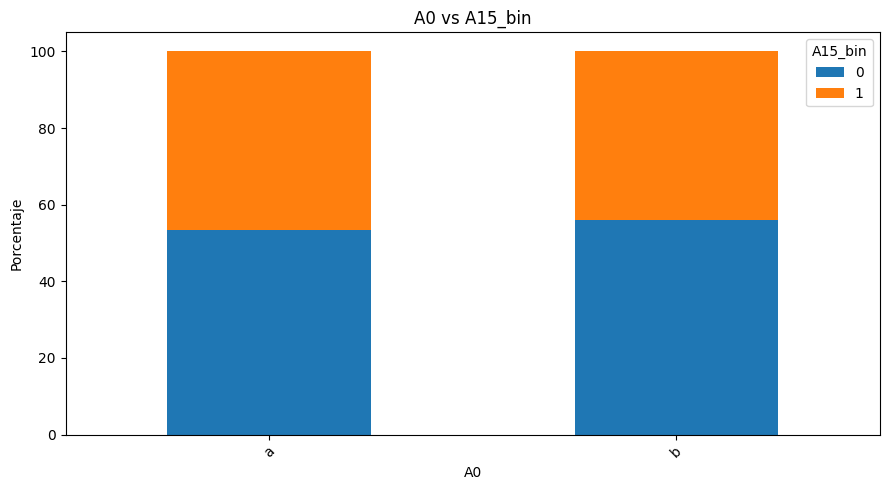

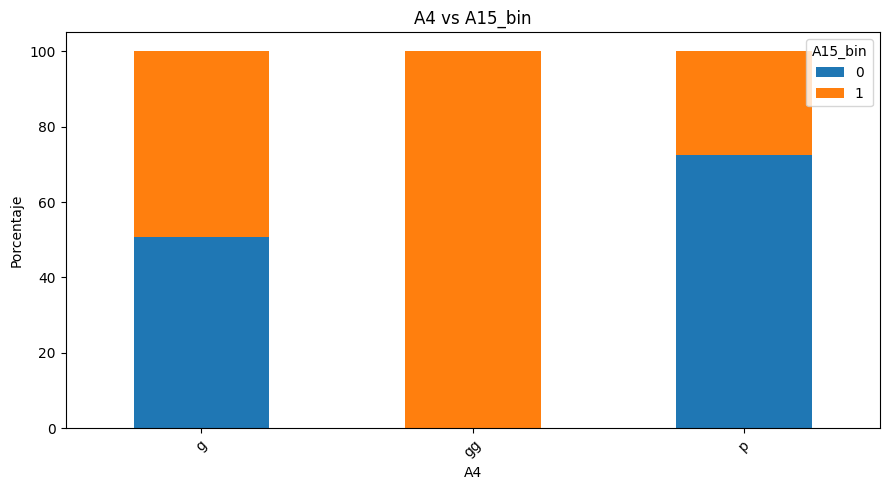

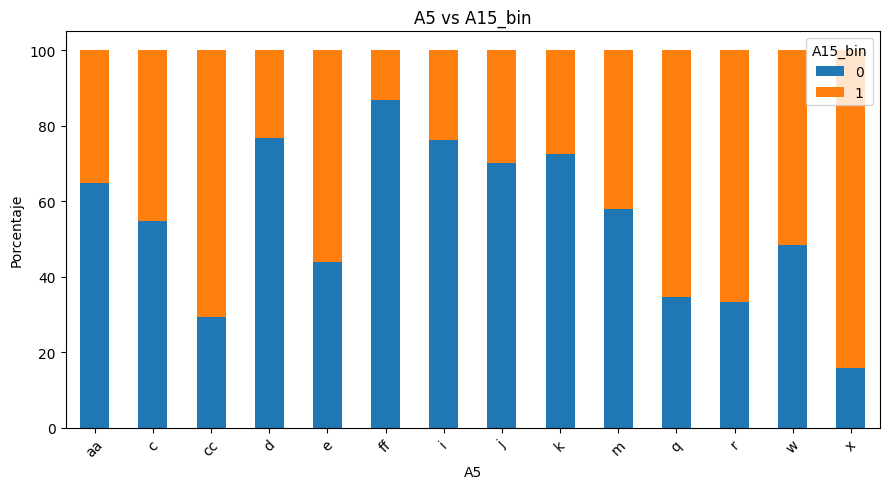

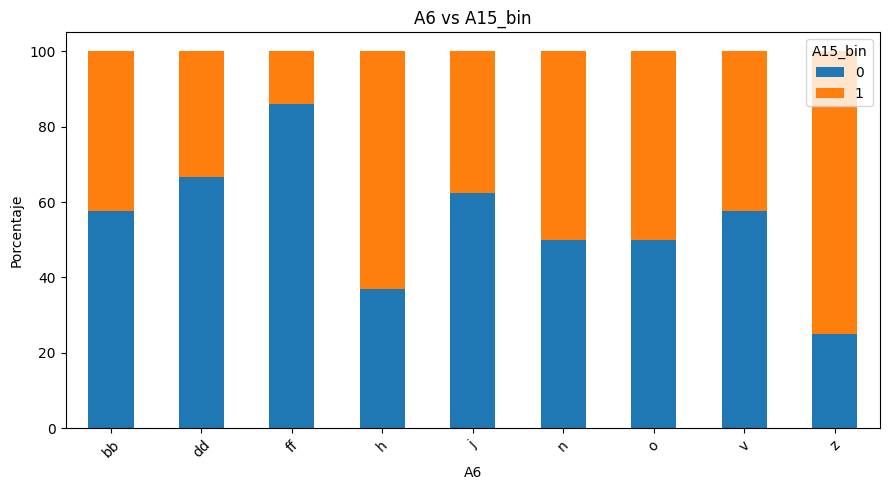

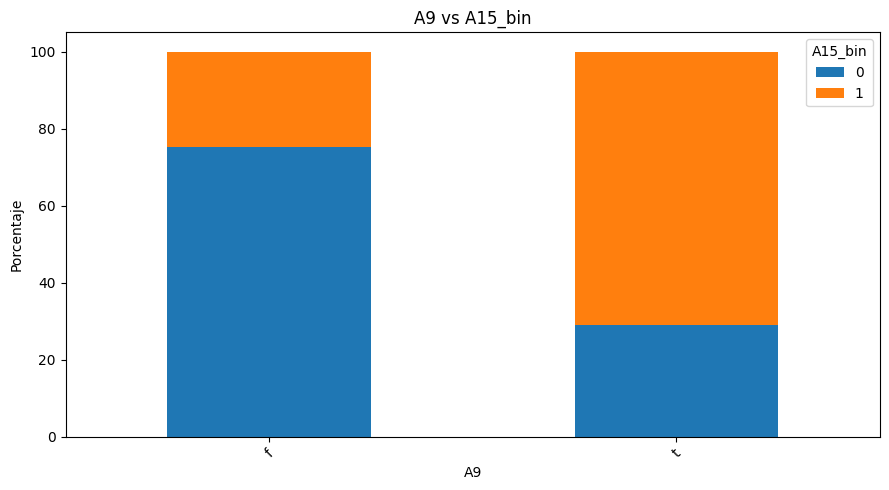

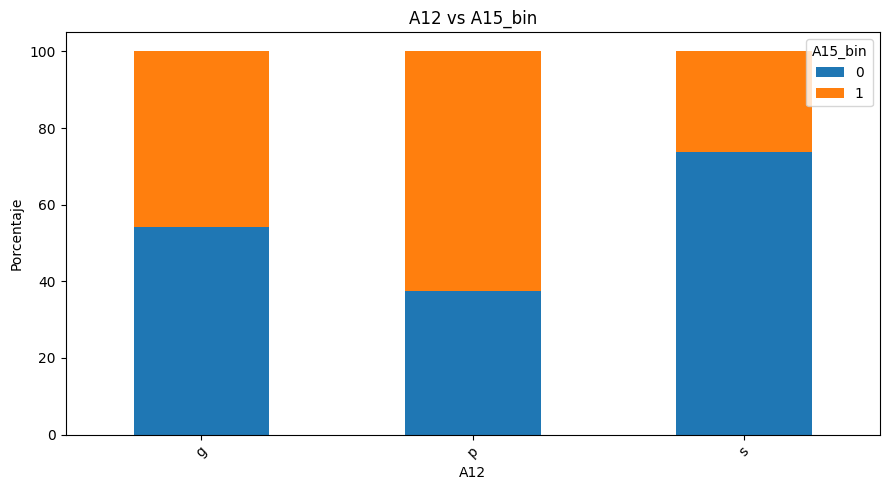

In [92]:
for variable in variables_categoricas:

    tabla = pd.crosstab(
        df[variable],
        df['A15_bin'], # Changed 'A15' to 'A15_bin'
        normalize='index'
    ) * 100

    tabla.plot(
        kind='bar',
        stacked=True,
        figsize=(9, 5)
    )

    plt.title(f'{variable} vs A15_bin') # Updated title
    plt.xlabel(variable)
    plt.ylabel('Porcentaje')
    plt.legend(title='A15_bin') # Updated legend title
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Se analizaron las variables categóricas mediante gráficos de barras apiladas que muestran el porcentaje de aprobaciones (A15 = 1) y rechazos (A15 = 0) dentro de cada categoría. Los resultados indican lo siguiente:

- A0: Las categorías a y b presentan proporciones muy similares de aprobación y rechazo, por lo que no se observa una relación importante con A15.
- A4: Se evidencian diferencias marcadas entre categorías. La categoría gg presenta un porcentaje de aprobación muy alto, mientras que p presenta una proporción mayor de rechazos. Esto sugiere una asociación con A15.
- A5: Varias categorías muestran comportamientos distintos. Algunas categorías presentan una alta proporción de aprobaciones y otras una alta proporción de rechazos, lo que indica una relación relevante con la variable objetivo.
- A6: También se observan diferencias importantes entre categorías. Por ejemplo, ciertas categorías presentan una proporción alta de aprobaciones, mientras que otras muestran predominio de rechazos.
- A9: La diferencia entre categorías es muy clara; la categoría t presenta una proporción considerablemente mayor de aprobaciones que la categoría f, por lo que esta variable parece estar fuertemente asociada con A15.
- A12: Existen diferencias visibles entre las categorías g, p y s, indicando una relación moderada con la variable objetivo.

En conclusión, las variables A4, A5, A6, A9 y A12 muestran una asociación visual con A15, mientras que A0 no evidencia una relación clara. Entre ellas, A9 es la variable que presenta la separación más evidente entre aprobados y rechazados, por lo que parece ser una de las mejores predictoras categóricas del conjunto de datos.

**De acuerdo con estos análisis, ¿cuáles variables parecerían ser buenas predictoras, y cuáles no?**

In [93]:
from scipy.stats import chi2_contingency

for variable in variables_categoricas:

    tabla = pd.crosstab(df[variable], df['A15'])

    chi2, p_valor, grados_libertad, esperados = chi2_contingency(tabla)

    print(f'Variable: {variable}')
    print(f'Chi-cuadrado: {chi2:.4f}')
    print(f'Valor p: {p_valor:.6f}')

    if p_valor < 0.05:
        print('Existe asociación estadísticamente significativa con A15')
    else:
        print('No se evidencia asociación estadísticamente significativa con A15')

    print('-' * 50)

Variable: A0
Chi-cuadrado: 0.3113
Valor p: 0.576894
No se evidencia asociación estadísticamente significativa con A15
--------------------------------------------------
Variable: A4
Chi-cuadrado: 26.2341
Valor p: 0.000002
Existe asociación estadísticamente significativa con A15
--------------------------------------------------
Variable: A5
Chi-cuadrado: 98.3252
Valor p: 0.000000
Existe asociación estadísticamente significativa con A15
--------------------------------------------------
Variable: A6
Chi-cuadrado: 45.0342
Valor p: 0.000000
Existe asociación estadísticamente significativa con A15
--------------------------------------------------
Variable: A9
Chi-cuadrado: 143.0696
Valor p: 0.000000
Existe asociación estadísticamente significativa con A15
--------------------------------------------------
Variable: A12
Chi-cuadrado: 9.1916
Valor p: 0.010094
Existe asociación estadísticamente significativa con A15
--------------------------------------------------


### Variables que parecen ser buenas predictoras y variables que no

Para evaluar la capacidad predictiva de las variables cualitativas respecto a la variable objetivo A15, se realizó la prueba de independencia chi-cuadrado. Se utilizó un nivel de significancia de 0.05.

Los resultados obtenidos fueron:

| Variable |  Valor p | Conclusión       |
| -------- | -------: | ---------------- |
| A0       | 0.576894 | No significativa |
| A4       | 0.000002 | Significativa    |
| A5       | 0.000000 | Significativa    |
| A6       | 0.000000 | Significativa    |
| A9       | 0.000000 | Significativa    |
| A12      | 0.010094 | Significativa    |

Con base en estos resultados, se concluye que las variables A4, A5, A6, A9 y A12 presentan una asociación estadísticamente significativa con A15, ya que sus valores p son menores a 0.05. Esto indica que las proporciones de aprobación y rechazo cambian según la categoría de estas variables, por lo que parecen ser buenas predictoras de la variable objetivo.

La variable **A9** es la que muestra la asociación más fuerte (chi-cuadrado = 143.61), seguida de **A5** y **A6**, por lo que son las candidatas más prometedoras para un modelo predictivo.

Por otro lado, la variable **A0 no presenta una asociación estadísticamente significativa con A15** (valor p = 0.576894), por lo que **no parece ser una buena predictora** de manera individual.

En conjunto, los análisis gráficos y estadísticos sugieren que las variables categóricas con mayor potencial predictivo son **A9, A5, A6, A4 y A12**, mientras que **A0 aporta poca información para predecir A15**.
